In [24]:
import anndata as ad
import pandas as pd
import numpy as np
from pathlib import Path
import scanpy as sc
#import squidpy as sq

In [25]:
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [26]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)
abc_cache.current_manifest

'releases/20260415/manifest.json'

In [27]:
cell = abc_cache.get_metadata_dataframe(
    directory='MERFISH-C57BL6J-638850',
    file_name='cell_metadata',
    dtype={"cell_label": str}
)
cell.set_index('cell_label', inplace=True)
cluster_details = abc_cache.get_metadata_dataframe(
    directory='WMB-taxonomy',
    file_name='cluster_to_cluster_annotation_membership_pivoted',
    keep_default_na=False
)
cluster_details.set_index('cluster_alias', inplace=True)

In [28]:
cluster_colors = abc_cache.get_metadata_dataframe(directory='WMB-taxonomy', file_name='cluster_to_cluster_annotation_membership_color')
cluster_colors.set_index('cluster_alias', inplace=True)
cell_extended = cell.join(cluster_details, on='cluster_alias')
cell_extended = cell_extended.join(cluster_colors, on='cluster_alias')

In [29]:
gene = abc_cache.get_metadata_dataframe(directory='MERFISH-C57BL6J-638850', file_name='gene')
gene.set_index('gene_identifier', inplace=True)

In [30]:
file = abc_cache.get_file_path(directory='MERFISH-C57BL6J-638850', file_name='C57BL6J-638850/log2')

C57BL6J-638850-log2.h5ad: 100%|██████████| 7.63G/7.63G [06:45<00:00, 18.8MB/s]    


In [32]:
adata = ad.read_h5ad(file, backed='r')

In [33]:
adata.obs.head()

,brain_section_label
cell_label,
1015221640100570419,C57BL6J-638850.01
1015221640100590598,C57BL6J-638850.01
1015221640100820600,C57BL6J-638850.01
1015221640100580476,C57BL6J-638850.01
1015221640100580189,C57BL6J-638850.01


Similar to  the Tutorial
We will ullustrate the tissue section C57BL6J-638850.38

In [58]:
adata_filtered = adata[adata.obs['brain_section_label'] == "C57BL6J-638850.38"].to_memory()

In [59]:
adata_filtered.obs.head()

,brain_section_label
cell_label,
1017092617101530168-1,C57BL6J-638850.38
1017092617101600264-1,C57BL6J-638850.38
1017092617101570130-1,C57BL6J-638850.38
1017092617101600254,C57BL6J-638850.38
1017092617101290732,C57BL6J-638850.38


In [62]:
adata_filtered.obs = adata_filtered.obs.join(
    cell_extended.drop(columns=['x', 'y', 'z', 'brain_section_label'], errors='ignore')
)

# align spatial coordinates safely
adata_filtered.obsm['spatial'] = cell_extended.reindex(
    adata_filtered.obs.index
)[['x', 'y', 'z']].to_numpy()

In [60]:
adata_filtered.obs.head()

,brain_section_label
cell_label,
1017092617101530168-1,C57BL6J-638850.38
1017092617101600264-1,C57BL6J-638850.38
1017092617101570130-1,C57BL6J-638850.38
1017092617101600254,C57BL6J-638850.38
1017092617101290732,C57BL6J-638850.38


In [63]:
adata_filtered.obsm["spatial"][:, 1] *= -1

In [66]:
adata_filtered.obs["class"] = adata_filtered.obs["class"].fillna("Unknown")

In [64]:
adata_filtered.obs["class_color"] = (
    adata_filtered.obs["class_color"]
    .fillna("#CCCCCC")
    .astype(str)
)

In [69]:
classes = adata_filtered.obs["class"].astype("category").cat.categories

In [71]:
palette = (
    adata_filtered.obs.groupby("class")["class_color"]
    .first()
)

/tmp/ipykernel_39686/94016161.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filtered.obs.groupby("class")["class_color"]


In [73]:
adata_filtered.uns["class_colors"] = [
    palette[c] for c in classes
]

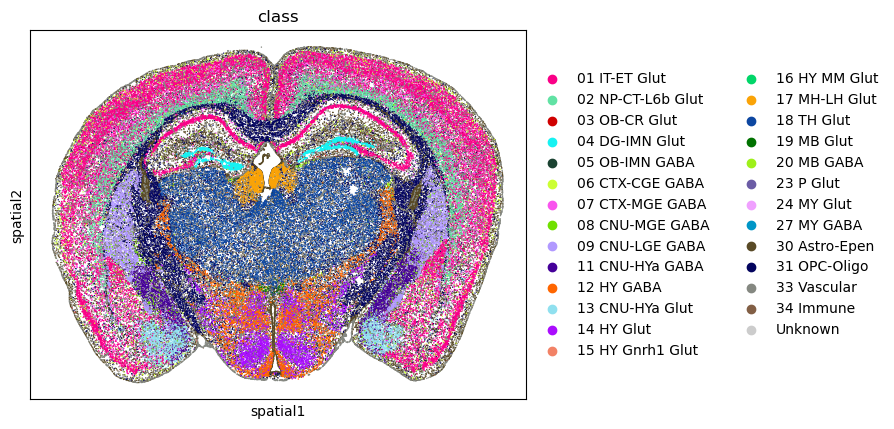

In [77]:
sc.pl.embedding(
    adata_filtered,
    basis="spatial",
    color="class",
    size=4
)

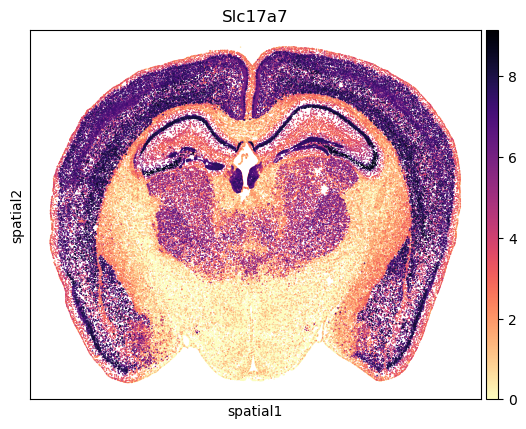

In [84]:
sc.pl.embedding(
    adata_filtered,
    basis="spatial",
    color="Slc17a7",
    gene_symbols="gene_symbol",
    cmap="magma_r",
    size=4
)